# Comparacion de sistemas

Este cuaderno deja preparado el analisis comparativo entre sistemas intensivos y extensivos. De momento solo hay datos intensivos de referencia, asi que el foco es dejar la estructura de comparacion lista para incorporar las granjas extensivas cuando lleguen.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

# BASE_DIR relativo (no ruta absoluta, criterio de calidad del TFM): funciona tanto si el
# notebook se ejecuta con cwd en la raiz del proyecto como si Jupyter lo abre con cwd en esta
# misma carpeta "experimentos".
BASE_DIR = Path.cwd()
if BASE_DIR.name == "experimentos":
    BASE_DIR = BASE_DIR.parent
REFERENCE_FILES = {
    "celso_diario": BASE_DIR / "Procesados" / "Celso novo" / "05_original_variables.csv",
    "celso_horario": BASE_DIR / "Procesados" / "Celso novo" / "04_Vacas_etiquetadas_horario.xlsx",
    "ruibal_horario": BASE_DIR / "Procesados" / "Ruibal Riomayor" / "05_Datos_horarios_etiquetados_celo.csv",
}


def load_dataset(path: Path) -> pd.DataFrame:
    if path.suffix.lower() == ".csv":
        df = pd.read_csv(path)
    else:
        df = pd.read_excel(path)
    df.columns = [column.strip() for column in df.columns]
    return df


def summarize_dataset(df: pd.DataFrame, dataset_name: str, system: str) -> pd.DataFrame:
    time_column = "Date" if "Date" in df.columns else "Time" if "Time" in df.columns else None
    summary = {
        "dataset": dataset_name,
        "system": system,
        "rows": int(df.shape[0]),
        "columns": int(df.shape[1]),
        "cow_count": int(df["Cow_id"].nunique()) if "Cow_id" in df.columns else pd.NA,
        "missing_values": int(df.isna().sum().sum()),
    }

    if time_column is not None:
        time_values = pd.to_datetime(df[time_column], errors="coerce")
        summary["start"] = time_values.min()
        summary["end"] = time_values.max()

    if "Anomaly_Label" in df.columns:
        labels = df["Anomaly_Label"].fillna("Sin etiqueta").astype(str).value_counts()
        summary["top_label"] = labels.index[0] if not labels.empty else pd.NA
        summary["top_label_count"] = int(labels.iloc[0]) if not labels.empty else pd.NA

    numeric_cols = [col for col in ["Ruminate", "Eat", "Graze", "Rest", "Walk", "Steps"] if col in df.columns]
    for column in numeric_cols:
        summary[f"mean_{column.lower()}"] = float(pd.to_numeric(df[column], errors="coerce").mean())

    return pd.DataFrame([summary])


reference_data = {name: load_dataset(path) for name, path in REFERENCE_FILES.items() if path.exists()}
comparison_table = pd.concat(
    [summarize_dataset(df, name, "intensivo") for name, df in reference_data.items()],
    ignore_index=True,
)

comparison_table

,dataset,system,rows,columns,cow_count,missing_values,start,end,top_label,top_label_count,mean_ruminate,mean_eat,mean_graze,mean_rest,mean_walk,mean_steps
0,celso_diario,intensivo,3755,10,16,0,2023-07-09,2025-08-03 00:00:00,No anomaly,3643,545.590345,396.863474,164.133418,300.905129,7.131602,3052.307324
1,celso_horario,intensivo,720131,9,108,718750,2023-07-09,2025-09-15 23:00:00,Sin etiqueta,718750,21.866702,17.566585,4.829941,14.164696,0.417596,152.572565
2,ruibal_horario,intensivo,454296,13,93,2229260,2024-03-08,2025-08-08 23:00:00,Sin etiqueta,442563,22.475503,19.528974,2.634343,14.067886,0.289344,147.083012


# Lectura rapida

De momento la tabla solo contiene sistemas intensivos. Cuando lleguen las granjas extensivas, se incorporan al mismo esquema para obtener la comparacion final entre sistemas.

,dataset,system,rows,columns,cow_count,missing_values,start,end,top_label,top_label_count,mean_ruminate,mean_eat,mean_graze,mean_rest,mean_walk,mean_steps
0,celso_diario,intensivo,3755,10,16,0,2023-07-09,2025-08-03 00:00:00,No anomaly,3643,545.590345,396.863474,164.133418,300.905129,7.131602,3052.307324
1,celso_horario,intensivo,720131,9,108,718750,2023-07-09,2025-09-15 23:00:00,Sin etiqueta,718750,21.866702,17.566585,4.829941,14.164696,0.417596,152.572565
2,ruibal_horario,intensivo,454296,13,93,2229260,2024-03-08,2025-08-08 23:00:00,Sin etiqueta,442563,22.475503,19.528974,2.634343,14.067886,0.289344,147.083012


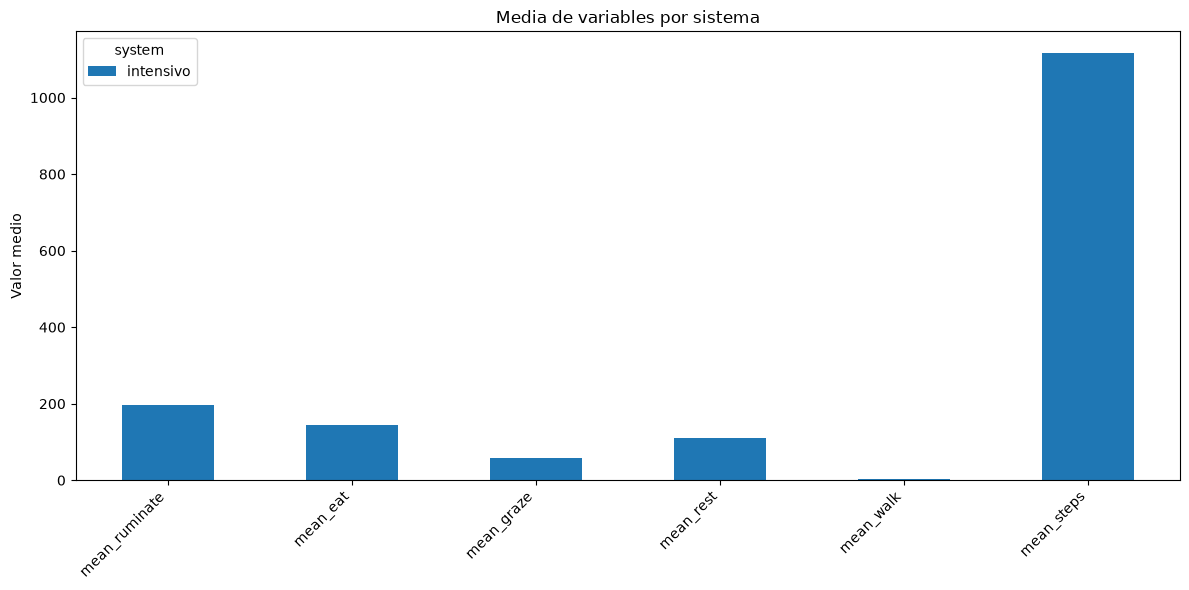

In [2]:
display(comparison_table)

if not comparison_table.empty:
    numeric_columns = [column for column in comparison_table.columns if column.startswith("mean_")]
    if numeric_columns:
        system_means = comparison_table.groupby("system")[numeric_columns].mean(numeric_only=True)
        ax = system_means.T.plot(kind="bar", figsize=(12, 6))
        ax.set_title("Media de variables por sistema")
        ax.set_ylabel("Valor medio")
        plt.xticks(rotation=45, ha="right")
        plt.tight_layout()
        plt.show()